# Fit LG — Twitter ego networks (`twitter`)

Batch fit and model comparison for **all networks** in this collection.

All Twitter ego nets with |V| ≥ 100 (`data/misc/twitter/*.edges`), sorted by |V|.

**Per network**, the fit loop logs four steps and saves a 4-panel report (`runs/twitter/{graph}/fit_report.png`):

1. **Load** — graph size and structural attributes  
2. **AIC** — pick `d̂` over candidates `[0,1,2,3]`  
3. **σ̂** — Layer-2 offset logit at `d̂`  
4. **Compare** — LG vs ER / WS / BA (`GraphModelComparator`, spectral GIC)

Aggregate tables and plots land in `runs/twitter/`. Full log: `runs/twitter/platform.log`.

## 1. Discover networks

In [1]:
import os
import sys
import warnings
from pathlib import Path

for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")
warnings.filterwarnings("ignore", category=DeprecationWarning)

_REFACTOR = Path.cwd()
if str(_REFACTOR) not in sys.path:
    sys.path.insert(0, str(_REFACTOR))

from platform_fit_utils import PlatformConfig, discover_graph_files, print_discovery

# ---- Batch settings (edit here) --------------------------------------------
MIN_NODES = 50
MAX_NODES = 500      # skip graphs with n > MAX_NODES; set None for no cap
USE_CACHE = True     # reload finished networks from runs/{platform}/{graph}/

cfg = PlatformConfig(
    platform="twitter",
    glob_pattern="misc/twitter/*.edges",
    min_nodes=MIN_NODES,
    max_nodes=MAX_NODES,
    use_cache=USE_CACHE,
    display_plots=False,
)

graph_files = discover_graph_files(cfg)
print_discovery(cfg, graph_files)

PLATFORM=twitter  RUN_DIR=/Users/maruanottoni/home/master/research/all_logit/logit-graph/notebooks/refactors/runs/twitter
Found 853 networks (MIN_NODES=50, MAX_NODES=500, USE_CACHE=True)
                  27595997.edges  n=   50  |E|=    228
                  49098552.edges  n=   50  |E|=    121
                 130734452.edges  n=   51  |E|=     72
                  16105942.edges  n=   51  |E|=    467
                  19283723.edges  n=   51  |E|=    329
                 207594668.edges  n=   51  |E|=    153
                  21364753.edges  n=   51  |E|=    456
                  25344777.edges  n=   51  |E|=    426
                 358845982.edges  n=   51  |E|=    686
                 430313102.edges  n=   51  |E|=    999
                  43194901.edges  n=   51  |E|=    249
                  21028234.edges  n=   52  |E|=    256
                  63084853.edges  n=   52  |E|=    625
                  21816783.edges  n=   53  |E|=    183
                   2890961.edges  n=   53  

## 2. Fit all networks

In [2]:
from platform_fit_utils import fit_all_networks

comparators, summary_all, fit_meta, failures = fit_all_networks(graph_files, cfg)
RUN_DIR = cfg.run_dir

19:34:32  === twitter batch fit  (853 networks, MAX_NODES=500, cache=True) ===
19:34:32  [1/853] 27595997
19:34:32    STEP 1/4  Load graph  n=50 |E|=228 density=0.1861 clustering=0.424 assort=0.002
19:34:32    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=1179.4  d=1:AIC=1011.7  d=2:AIC=1123.2  d=3:AIC=1317.0)  [0.2s]
19:34:32    STEP 3/4  Estimate σ at d̂  σ̂=-2.7070  [0.0s]
19:34:32    STEP 4/4  Model comparison  LG max_iter=4000  baselines=ER/WS/BA

============================== Processing Graph: 27595997 ==============================

--- Fitting Logit Graph (LG) model ---
Running LG generation for d=1 (warm_start_p=0.0626)...


Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 300 (GIC: 4.4883). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,800
  Best spectrum diff: 30.4218
  Edges in best graph: 138 (real: 228)
d=1: GIC=4.4970, sigma=-2.7070
Best LG fit found with GIC: 4.4970

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 5.801106298968243
Testing the selected model for WS
WS gic: 5.3450735866169685
Testing the selected model for BA
BA gic: 5.772244433127454
WS fitting - GIC: 5.3451, Param: 80.5000
BA fitting - GIC: 5.7722, Param: 6.2500
ER fitting - GIC: 5.8011, Param: 0.1900

--- Calculating graph attributes ---
19:34:32    RESULT  best=LG  GIC=4.497  (LG=4.497  WS=5.345  BA=5.772  ER=5.801)  [compare 0.3s | total 0.5s]
19:34:32    Saved fit_report.png
19:34:32  [2/853] 49098552
19:34:32    STEP 1/4  Load graph  n=50 |E|=121 density=0.0988 clustering=0.414 assort=-0.201
19:34:32    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=791.8

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 450 (GIC: 4.8321). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,900
  Best spectrum diff: 10.8396
  Edges in best graph: 103 (real: 121)
d=1: GIC=7.9909, sigma=-2.8593
Best LG fit found with GIC: 7.9909

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 6.9873020505916745
Testing the selected model for WS
WS gic: 7.028801023138319
Testing the selected model for BA
BA gic: 8.599931124978145
ER fitting - GIC: 6.9873, Param: 0.1300
WS fitting - GIC: 7.0288, Param: 60.3775
BA fitting - GIC: 8.5999, Param: 4.5000

--- Calculating graph attributes ---
19:34:33    RESULT  best=ER  GIC=6.987  (ER=6.987  WS=7.029  LG=7.991  BA=8.600)  [compare 0.2s | total 0.2s]
19:34:33    Saved fit_report.png
19:34:33  [3/853] 130734452
19:34:33    STEP 1/4  Load graph  n=51 |E|=72 density=0.0565 clustering=0.103 assort=-0.063
19:34:33    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=555.7

...

GIC threshold 5 reached at iteration 0 (GIC: 0.9217). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,950
  Best spectrum diff: 208.0883
  Edges in best graph: 507 (real: 1318)
d=1: GIC=3.4031, sigma=-2.7152
Best LG fit found with GIC: 3.4031

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 4.852146008876487
Testing the selected model for WS
WS gic: 7.8381766452934425
Testing the selected model for BA
BA gic: 3.8831408914356835
BA fitting - GIC: 3.8831, Param: 8.0000
ER fitting - GIC: 4.8521, Param: 0.2500
WS fitting - GIC: 7.8382, Param: 80.0100

--- Calculating graph attributes ---
19:37:07    RESULT  best=LG  GIC=3.403  (LG=3.403  BA=3.883  ER=4.852  WS=7.838)  [compare 0.6s | total 0.7s]
19:37:07    Saved fit_report.png
19:37:07  [239/853] 22958268
19:37:07    STEP 1/4  Load graph  n=99 |E|=753 density=0.1552 clustering=0.448 assort=0.179
19:37:07    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=419

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 0.6572). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,950
  Best spectrum diff: 116.7912
  Edges in best graph: 337 (real: 753)
d=1: GIC=4.3321, sigma=-2.9049
Best LG fit found with GIC: 4.3321

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 7.732032521610753
Testing the selected model for WS
WS gic: 6.483493802371201
Testing the selected model for BA
BA gic: 6.8779318861134815
WS fitting - GIC: 6.4835, Param: 80.1325
BA fitting - GIC: 6.8779, Param: 8.0000
ER fitting - GIC: 7.7320, Param: 0.1900

--- Calculating graph attributes ---
19:37:07    RESULT  best=LG  GIC=4.332  (LG=4.332  WS=6.483  BA=6.878  ER=7.732)  [compare 0.5s | total 0.6s]
19:37:08    Saved fit_report.png
19:37:08  [240/853] 66185823
19:37:08    STEP 1/4  Load graph  n=99 |E|=1232 density=0.2540 clustering=0.564 assort=-0.073
19:37:08    STEP 2/4  AIC select d  d̂=1  (d=0:AIC=549

Optimizing Graph:   0%|          | 0/4000 [00:00<?, ?it/s] 

GIC threshold 5 reached at iteration 0 (GIC: 0.7764). Starting spectrum patience (500 checks).

Stopping: max iterations (4,000) reached
  Best iteration: 3,950
  Best spectrum diff: 204.6654
  Edges in best graph: 415 (real: 1232)
d=1: GIC=3.3912, sigma=-2.7649
Best LG fit found with GIC: 3.3912

--- Fitting other random graph models ---
Testing the selected model for ER
ER gic: 4.244364401989889
Testing the selected model for WS
WS gic: 5.10924838593391
Testing the selected model for BA
BA gic: 3.7506229415226664
BA fitting - GIC: 3.7506, Param: 8.0000
ER fitting - GIC: 4.2444, Param: 0.2500
WS fitting - GIC: 5.1092, Param: 80.1325

--- Calculating graph attributes ---
19:37:08    RESULT  best=LG  GIC=3.391  (LG=3.391  BA=3.751  ER=4.244  WS=5.109)  [compare 0.5s | total 0.7s]
19:37:08    Saved fit_report.png
19:37:09  [241/853] 134208594  CACHED  (n=100, best=ER, GIC=3.190)
19:37:09  [242/853] 18687625  CACHED  (n=101, best=ER, GIC=2.742)
19:37:09  [243/853] 18690700  CACHED  (n=101

## 3. Aggregate comparison

In [3]:
from platform_fit_utils import summarize_aggregates

gic_pivot, rank_pivot, mean_rank = summarize_aggregates(summary_all, RUN_DIR)

Mean GIC rank by model (lower = better):
model
LG    1.536
BA    2.152
WS    3.101
ER    3.211
dtype: float64

model               LG      ER      WS      BA
graph_filename                                
12831            3.341   4.321   4.448   4.327
78813            2.968   6.066   4.452   3.410
356963           3.113   6.669   6.901   5.968
623623           2.757   3.545   4.613   4.764
629863           4.109   4.837   5.580   7.118
745823           4.721   9.271   5.130   5.257
759679           4.126   7.574   5.316   6.528
778446           3.508   5.376   4.621   4.648
779715           3.074   5.669   4.628   4.029
789071           3.640   9.752   5.428   6.159
790205           3.551   7.422   5.781   3.697
809864           3.191   6.864   4.735   3.723
926981           3.452   6.211   4.989   3.174
1046661          3.085   5.057   5.240   4.906
1271901          3.536   4.518   4.920   3.935
1367531          3.435   3.056   5.495   3.161
1422311          3.791   6.089   5.183   3.

## 4. Summary plots

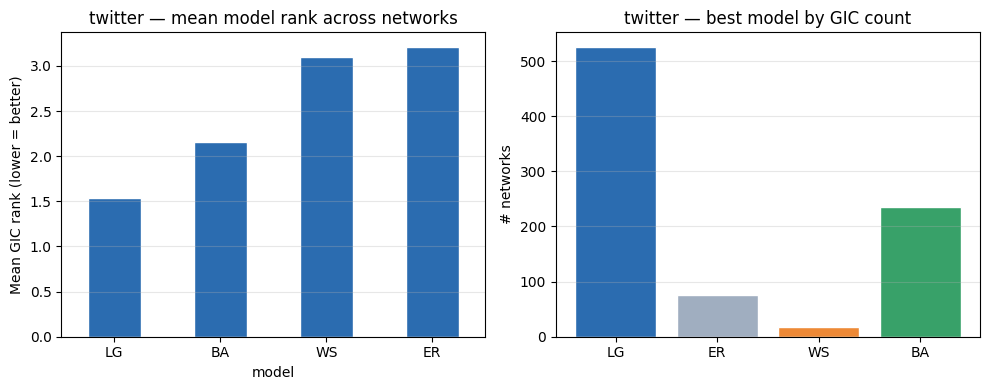

Saved runs/twitter/aggregate_model_comparison.png


PosixPath('runs/twitter/aggregate_model_comparison.png')

In [4]:
from platform_fit_utils import plot_aggregate_summary

plot_aggregate_summary(fit_meta, mean_rank, RUN_DIR, cfg.platform, display=True)